# Анализ мимики при болезни Паркинсона

**Цель.** Проанализировать, можно ли по коротким видеозаписям мимических проб отличить пациентов с болезнью Паркинсона от здоровых людей из контрольной группы с помощью машинного обучения.

**Задачи:**

1. Загрузить признаки сессий из базы данных.
2. Сравнить группы БП и КГ по каждому признаку с помощью теста Манна-Уитни.
3. Обучить три классификатора с Leave-One-Out Cross-Validation, оценить метрики качества.
4. Разобрать, какие признаки вносят наибольший вклад в классификацию.

**Данные.** На момент анализа в базе 11 сессий зажмуривания - 4 БП, 7 КГ и 9 сессий улыбки - 3 БП, 6 КГ. Выборка пилотная. Leave-One-Out здесь единственная разумная схема валидации: другие варианты отрезали бы слишком большую долю данных на тест.

**Методика.** MediaPipe Face Mesh покадрово снимает 468 точек лица. Для зажмуривания считается EAR (Eye Aspect Ratio), для улыбки берётся индекс ширины рта, нормированный по межзрачковому расстоянию. Оба индекса нормируются: baseline это медиана первых 15 кадров, top это 95-й перцентиль. Из нормированного временного ряда вытаскиваются 6 скалярных признаков: медиана, стандартное отклонение, максимум, максимальная скорость изменения, доля времени выше 0,5, частота пиков.

**Структура проекта.**
1. Импорты и подключение к БД
2. Загрузка данных из БД
3. Описательная статистика по группам
4. Визуализация распределения признаков
5. Статистический тест Манна-Уитни
6. Машинное обучение, LOOCV
7. Confusion matrices
8. Графики полученных метрик
9. Важность признаков, Random Forest
10. Выводы

## 1. Импорты и подключение к БД

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, average_precision_score, precision_recall_curve

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

DB_PATH = '../data/bts.db'
FEATURE_NAMES = [
    'Медиана',
    'Стандартное отклонение',
    'Максимум',
    'Максимальная скорость изменения',
    'Доля времени выше 0,5',
    'Частота пиков',
]

## 2. Загрузка данных из БД

Каждая сессия это одно загруженное видео. Признаки извлекаются автоматически при загрузке через веб-интерфейс.

In [2]:
conn = sqlite3.connect(DB_PATH)

sessions = pd.read_sql_query("""
    SELECT s.id AS session_id, s.test_type, p."group" AS group_code, s.quality_score
    FROM sessions s
    JOIN patients p ON p.id = s.patient_id
    WHERE s.status = 'done'
""", conn)

features = pd.read_sql_query("SELECT session_id, name, value FROM features", conn)
conn.close()

if len(sessions) == 0 or len(features) == 0:
    df = pd.DataFrame(columns=["session_id", "test_type", "group"] + FEATURE_NAMES)
    print("В БД пока нет обработанных сессий. Загрузите видео через веб-интерфейс, потом перезапустите ноутбук.")
else:
    features_wide = features.pivot_table(index="session_id", columns="name", values="value", aggfunc="first").reset_index()
    df = sessions.merge(features_wide, on="session_id", how="inner")
    df["group"] = df["group_code"].map({"BP": "БП", "KG": "КГ"})
    # оставляем только сессии, где есть все нужные признаки
    present = [f for f in FEATURE_NAMES if f in df.columns]
    if len(present) < len(FEATURE_NAMES):
        missing = set(FEATURE_NAMES) - set(present)
        print(f"⚠ Не все признаки найдены в БД: отсутствуют {missing}")
    if present:
        df = df.dropna(subset=present)
    print(f"Всего сессий с признаками: {len(df)}")
    if len(df) > 0:
        print(df.groupby(["test_type", "group"]).size().unstack(fill_value=0))

df.head()


Всего сессий с признаками: 20
group      БП  КГ
test_type        
blink       4   7
smile       3   6


,session_id,test_type,group_code,quality_score,"Доля времени выше 0,5",Максимальная скорость изменения,Максимум,Медиана,Среднее значение,Стандартное отклонение,Частота пиков,group
0,1,blink,BP,0.998347,0.483444,0.200000,1.000000,0.435226,NaN,0.393274,0.062914,БП
1,2,blink,BP,1.000000,0.568579,0.200000,1.000000,0.717801,NaN,0.400897,0.069825,БП
2,3,blink,BP,1.000000,0.918919,0.200000,0.992071,0.785434,NaN,0.223164,0.117117,БП
3,4,blink,BP,1.000000,0.918919,0.200000,0.992071,0.785434,NaN,0.223164,0.117117,БП
4,5,smile,BP,0.999143,0.581475,0.157331,1.000000,0.584635,NaN,0.312566,0.087479,БП


## 3. Описательная статистика по группам

In [3]:
for test in ['blink', 'smile']:
    sub = df[df['test_type'] == test]
    if len(sub) == 0:
        continue
    print(f'\n=== Проба: {test} ===')
    stats = sub.groupby('group')[FEATURE_NAMES].agg(['mean', 'std']).round(3).T
    stats.index.names = ['Признак', 'Статистика']
    display(stats)


=== Проба: blink ===


group                                          БП     КГ
Признак                         Статистика              
Медиана                         mean        0.681  0.774
                                std         0.167  0.120
Стандартное отклонение          mean        0.310  0.300
                                std         0.100  0.052
Максимум                        mean        0.996  0.988
                                std         0.005  0.021
Максимальная скорость изменения mean        0.200  0.199
                                std         0.000  0.001
Доля времени выше 0,5           mean        0.722  0.747
                                std         0.229  0.133
Частота пиков                   mean        0.092  0.121
                                std         0.029  0.051


=== Проба: smile ===


group                                          БП     КГ
Признак                         Статистика              
Медиана                         mean        0.486  0.609
                                std         0.086  0.166
Стандартное отклонение          mean        0.322  0.343
                                std         0.018  0.022
Максимум                        mean        1.000  0.999
                                std         0.000  0.002
Максимальная скорость изменения mean        0.182  0.193
                                std         0.022  0.005
Доля времени выше 0,5           mean        0.489  0.563
                                std         0.080  0.111
Частота пиков                   mean        0.059  0.051
                                std         0.025  0.010

## 4. Визуализация распределения признаков

Графики показывают, как распределены значения признаков в каждой группе. Если боксы не пересекаются, признак хорошо разделяет группы.

/var/folders/9t/f4tq965s2k11z6djq3rp_8r00000gn/T/ipykernel_55657/3221592459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='group', y=feat, ax=ax, order=['КГ', 'БП'], palette={'КГ': '#7fb069', 'БП': '#e07a5f'})
/var/folders/9t/f4tq965s2k11z6djq3rp_8r00000gn/T/ipykernel_55657/3221592459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='group', y=feat, ax=ax, order=['КГ', 'БП'], palette={'КГ': '#7fb069', 'БП': '#e07a5f'})
/var/folders/9t/f4tq965s2k11z6djq3rp_8r00000gn/T/ipykernel_55657/3221592459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

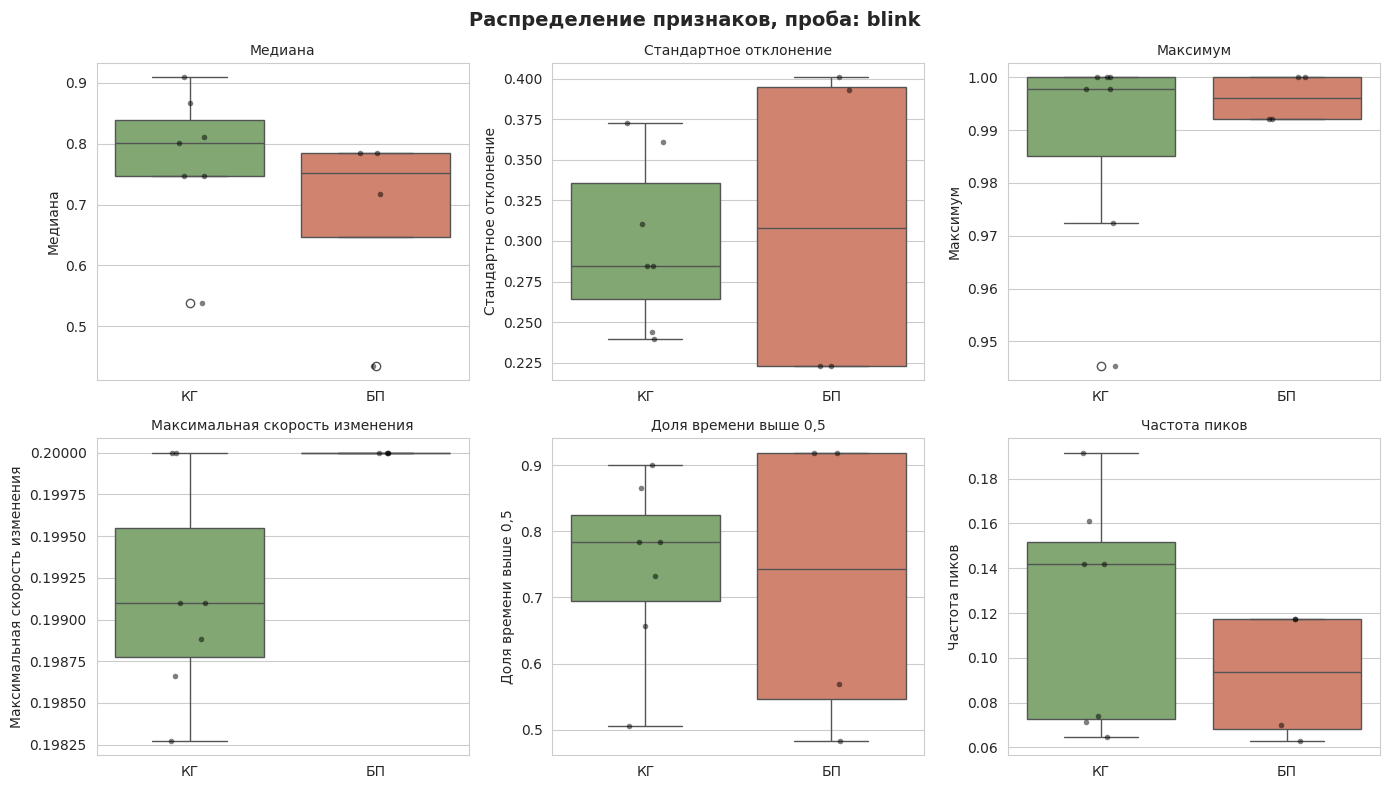

/var/folders/9t/f4tq965s2k11z6djq3rp_8r00000gn/T/ipykernel_55657/3221592459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='group', y=feat, ax=ax, order=['КГ', 'БП'], palette={'КГ': '#7fb069', 'БП': '#e07a5f'})
/var/folders/9t/f4tq965s2k11z6djq3rp_8r00000gn/T/ipykernel_55657/3221592459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='group', y=feat, ax=ax, order=['КГ', 'БП'], palette={'КГ': '#7fb069', 'БП': '#e07a5f'})
/var/folders/9t/f4tq965s2k11z6djq3rp_8r00000gn/T/ipykernel_55657/3221592459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

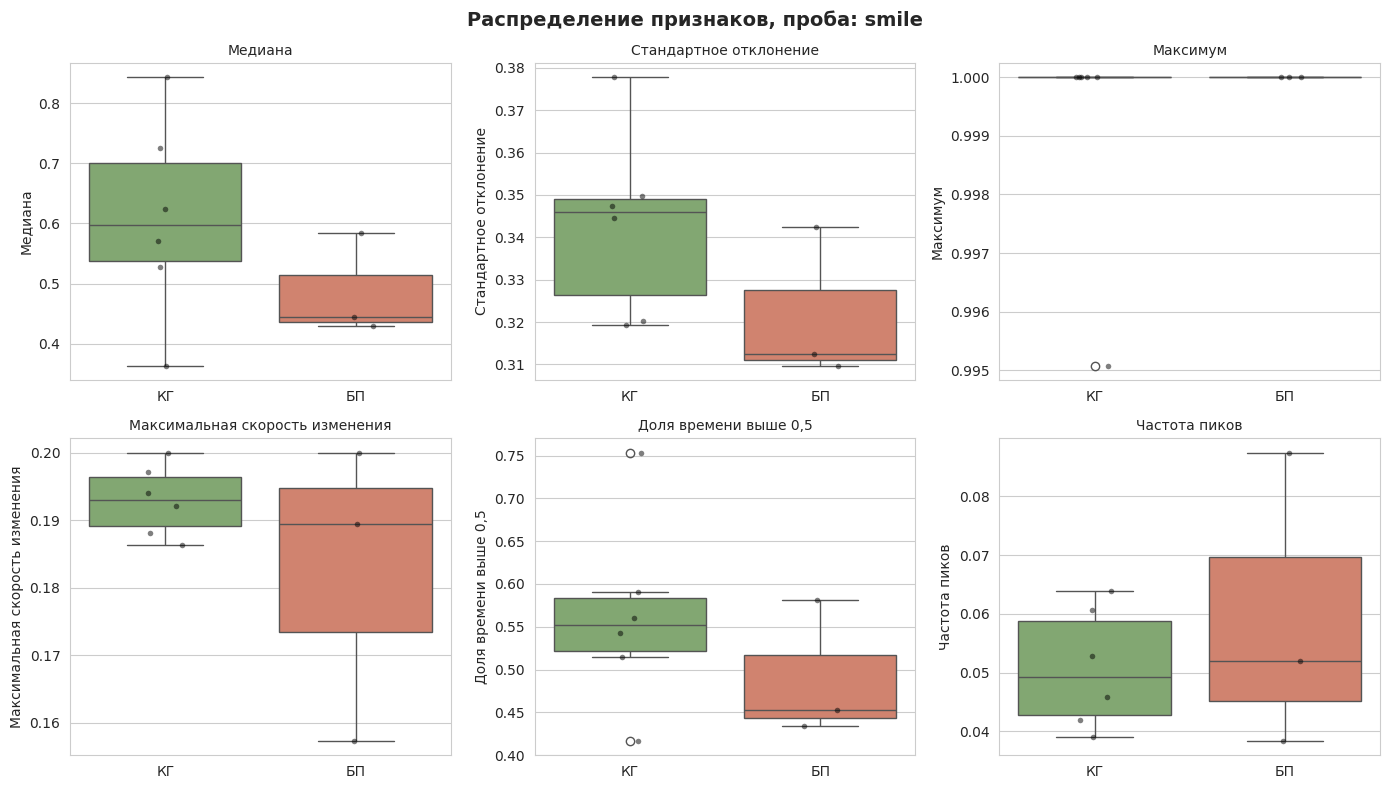

In [4]:
for test in ['blink', 'smile']:
    sub = df[df['test_type'] == test]
    if len(sub) < 2:
        continue
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(f'Распределение признаков, проба: {test}', fontsize=14, fontweight='bold')
    for ax, feat in zip(axes.flat, FEATURE_NAMES):
        sns.boxplot(data=sub, x='group', y=feat, ax=ax, order=['КГ', 'БП'], palette={'КГ': '#7fb069', 'БП': '#e07a5f'})
        sns.stripplot(data=sub, x='group', y=feat, ax=ax, order=['КГ', 'БП'], color='black', size=4, alpha=0.5)
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

## 5. Статистический тест Манна-Уитни

Непараметрический тест на различие распределений между группами. Значение **p-value < 0.05** говорит, что различие статистически значимо.

In [5]:
for test in ['blink', 'smile']:
    sub = df[df['test_type'] == test]
    bp = sub[sub['group'] == 'БП']
    kg = sub[sub['group'] == 'КГ']
    if len(bp) < 2 or len(kg) < 2:
        print(f'\nПроба {test}: недостаточно данных')
        continue
    rows = []
    for feat in FEATURE_NAMES:
        u, p = mannwhitneyu(bp[feat], kg[feat], alternative='two-sided')
        rows.append({'Признак': feat, 'U': round(u, 2), 'p-value': round(p, 4),
                     'Значимо (p<0.05)': '✓' if p < 0.05 else ''})
    print(f'\n=== Проба: {test} (n_БП={len(bp)}, n_КГ={len(kg)}) ===')
    display(pd.DataFrame(rows))


=== Проба: blink (n_БП=4, n_КГ=7) ===


,Признак,U,p-value,Значимо (p<0.05)
0,Медиана,7.0,0.2172,
1,Стандартное отклонение,14.0,1.0000,
2,Максимум,15.0,0.9207,
3,Максимальная скорость изменения,23.0,0.1034,
4,"Доля времени выше 0,5",15.0,0.9244,
5,Частота пиков,7.0,0.2172,



=== Проба: smile (n_БП=3, n_КГ=6) ===


,Признак,U,p-value,Значимо (p<0.05)
0,Медиана,5.0,0.3810,
1,Стандартное отклонение,2.0,0.0952,
2,Максимум,10.5,0.6374,
3,Максимальная скорость изменения,7.5,0.7954,
4,"Доля времени выше 0,5",6.0,0.5476,
5,Частота пиков,9.0,1.0000,


## 6. Машинное обучение, LOOCV

Leave-One-Out Cross-Validation. На каждой итерации одна сессия идёт в тест, остальные в обучение. После всех итераций считаются метрики.

Используются три классификатора:

- **Random Forest**, 200 деревьев, class_weight='balanced'. Ансамблевый метод, устойчив к выбросам, даёт интерпретируемую важность признаков.
- **SVM с RBF-ядром**, StandardScaler перед обучением, probability=True, balanced class weight. Нелинейный классификатор, часто берут для биомедицинских данных.
- **Логистическая регрессия** со StandardScaler. Линейный baseline, нормально работает на малых выборках.

Метрики:

- **Accuracy**: доля правильных предсказаний.
- **F1**: гармоническое среднее точности и полноты.
- **ROC-AUC**: качество ранжирования, не зависит от баланса классов.
- **PR-AUC** или average precision: площадь под precision-recall кривой, при дисбалансе информативнее ROC-AUC. Базовый уровень равен доле БП в выборке.

In [6]:
def run_loocv(X, y, feature_names):
    classifiers = {
        'Random Forest': Pipeline([('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))]),
        'SVM (RBF)': Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42, class_weight='balanced'))]),
        'Лог. регрессия': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))]),
    }
    results = {}
    loo = LeaveOneOut()
    for name, pipe in classifiers.items():
        y_true, y_pred, y_prob = [], [], []
        importances = []
        for tr, te in loo.split(X):
            if len(np.unique(y[tr])) < 2:
                continue
            pipe.fit(X[tr], y[tr])
            y_true.append(int(y[te][0]))
            y_pred.append(int(pipe.predict(X[te])[0]))
            y_prob.append(float(pipe.predict_proba(X[te])[0, 1]))
            if name == 'Random Forest':
                importances.append(pipe.named_steps['clf'].feature_importances_)
        y_true_arr = np.array(y_true)
        y_prob_arr = np.array(y_prob)
        has_both = len(set(y_true)) > 1
        results[name] = {
            'y_true': y_true_arr, 'y_pred': np.array(y_pred), 'y_prob': y_prob_arr,
            'accuracy': accuracy_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, y_prob) if has_both else float('nan'),
            'pr_auc': average_precision_score(y_true, y_prob) if has_both else float('nan'),
            'confusion': confusion_matrix(y_true, y_pred, labels=[0, 1]),
            'importances': np.mean(importances, axis=0) if importances else None,
        }
    return results

all_results = {}
for test in ['blink', 'smile']:
    sub = df[df['test_type'] == test]
    if len(sub) < 3:
        continue
    X = sub[FEATURE_NAMES].values
    y = (sub['group'] == 'БП').astype(int).values
    all_results[test] = run_loocv(X, y, FEATURE_NAMES)
    baseline_pr = float(y.mean())
    print(f'\n=== Проба: {test} (n={len(sub)}, БП={int(y.sum())}, КГ={int((1-y).sum())}) ===')
    print(f'PR-AUC случайного классификатора (baseline): {baseline_pr:.3f}')
    summary = pd.DataFrame({
        clf: {'Accuracy': r['accuracy'], 'F1': r['f1'], 'ROC-AUC': r['roc_auc'], 'PR-AUC': r['pr_auc']}
        for clf, r in all_results[test].items()
    }).T.round(3)
    display(summary)



=== Проба: blink (n=11, БП=4, КГ=7) ===
PR-AUC случайного классификатора (baseline): 0.364


,Accuracy,F1,ROC-AUC,PR-AUC
Random Forest,0.636,0.500,0.821,0.793
SVM (RBF),0.545,0.444,0.000,0.269
Лог. регрессия,0.636,0.600,0.821,0.768



=== Проба: smile (n=9, БП=3, КГ=6) ===
PR-AUC случайного классификатора (baseline): 0.333


,Accuracy,F1,ROC-AUC,PR-AUC
Random Forest,0.444,0.000,0.250,0.306
SVM (RBF),0.444,0.000,0.000,0.242
Лог. регрессия,0.556,0.333,0.333,0.333


## 7. Confusion matrices

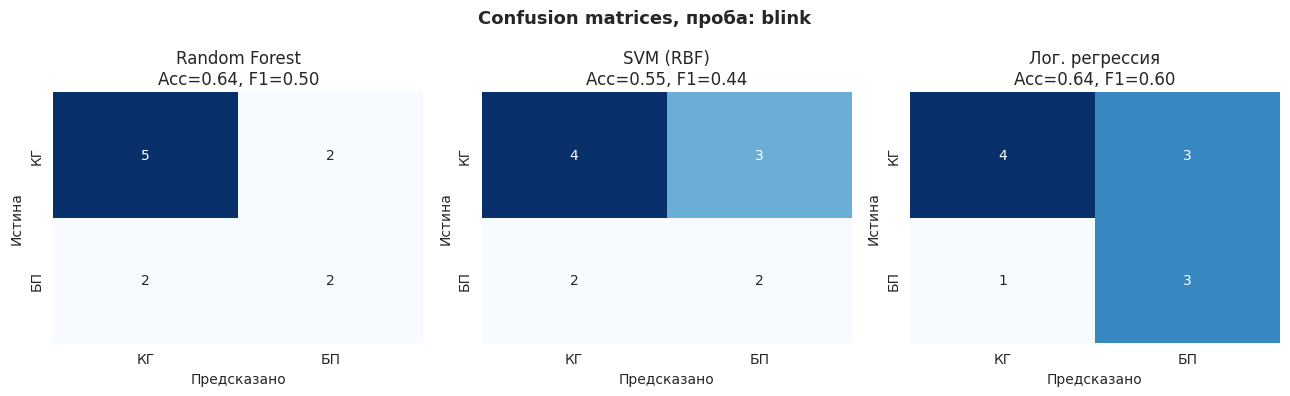

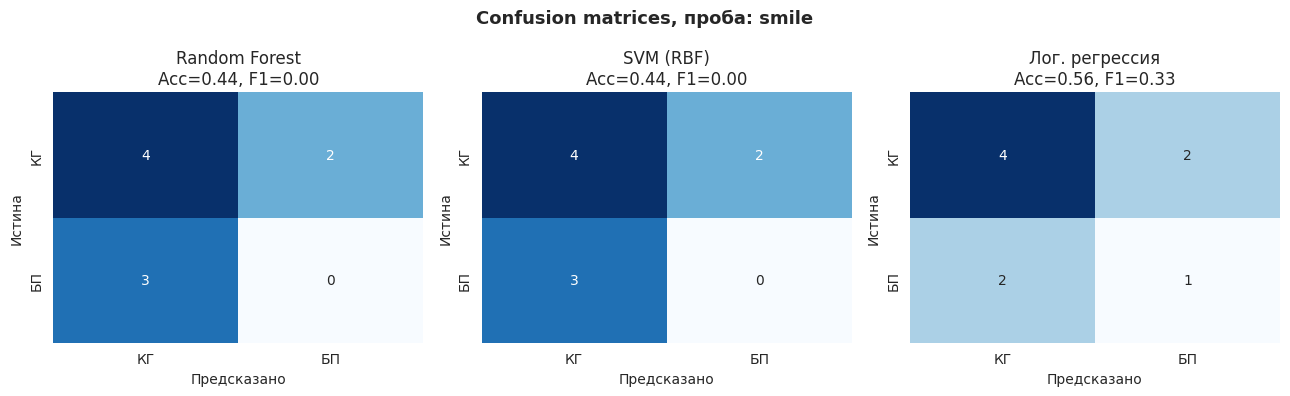

In [7]:
for test, results in all_results.items():
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle(f'Confusion matrices, проба: {test}', fontsize=13, fontweight='bold')
    for ax, (name, r) in zip(axes, results.items()):
        sns.heatmap(r['confusion'], annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['КГ', 'БП'], yticklabels=['КГ', 'БП'], cbar=False)
        ax.set_title(f'{name}\nAcc={r["accuracy"]:.2f}, F1={r["f1"]:.2f}')
        ax.set_xlabel('Предсказано')
        ax.set_ylabel('Истина')
    plt.tight_layout()
    plt.show()

## 8. ROC-кривые

ROC-AUC показывает качество ранжирования. Значение 1.0 идеально, 0.5 на уровне случайного угадывания.

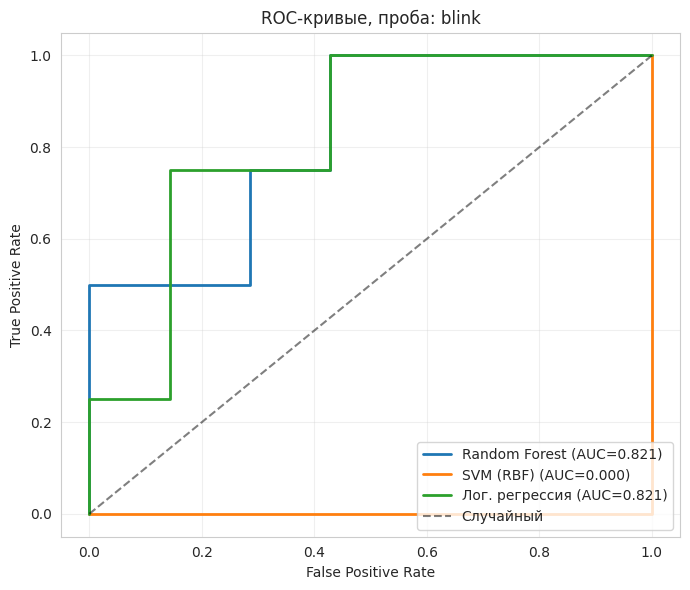

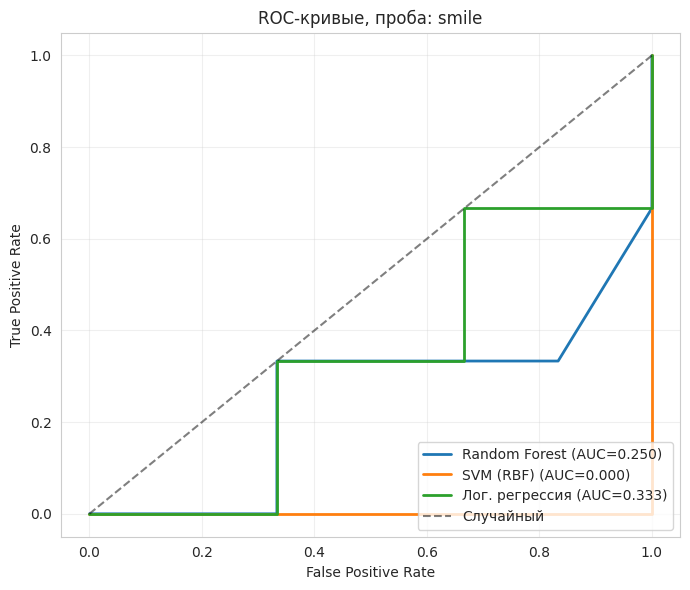

In [8]:
for test, results in all_results.items():
    plt.figure(figsize=(7, 6))
    for name, r in results.items():
        if len(set(r['y_true'])) < 2:
            continue
        fpr, tpr, _ = roc_curve(r['y_true'], r['y_prob'])
        plt.plot(fpr, tpr, label=f'{name} (AUC={r["roc_auc"]:.3f})', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC-кривые, проба: {test}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8b. PR-кривые, Precision-Recall

При несбалансированных классах PR-кривые информативнее ROC. Чем выше площадь, тем лучше модель удерживает точность при росте полноты.

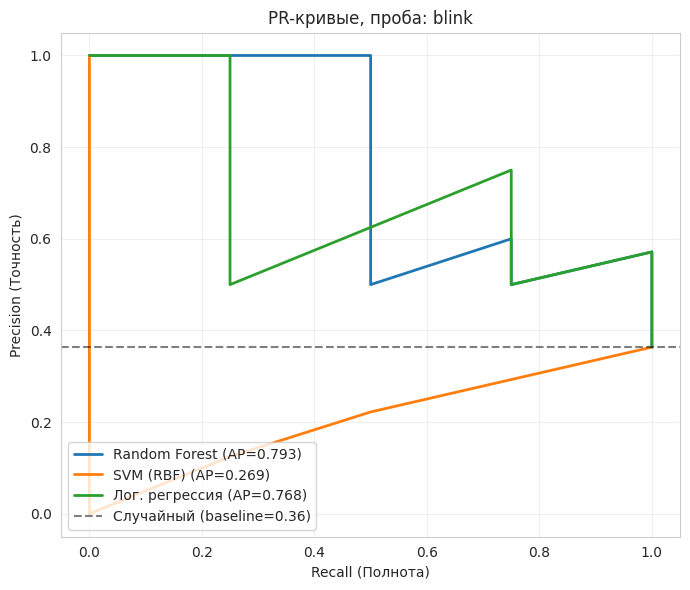

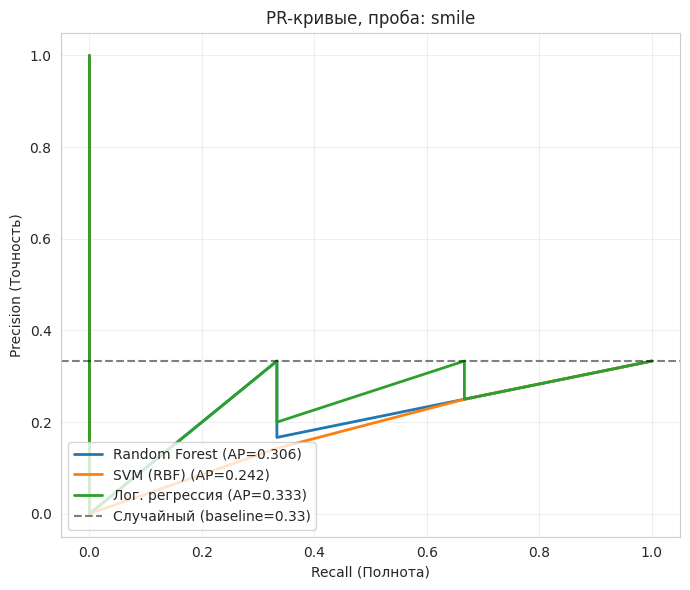

In [9]:
for test, results in all_results.items():
    plt.figure(figsize=(7, 6))
    baseline_pr = float((df[df['test_type'] == test]['group'] == 'БП').mean())
    for name, r in results.items():
        if len(set(r['y_true'])) < 2:
            continue
        prec, rec, _ = precision_recall_curve(r['y_true'], r['y_prob'])
        plt.plot(rec, prec, label=f'{name} (AP={r["pr_auc"]:.3f})', lw=2)
    plt.axhline(baseline_pr, ls='--', color='k', alpha=0.5, label=f'Случайный (baseline={baseline_pr:.2f})')
    plt.xlabel('Recall (Полнота)')
    plt.ylabel('Precision (Точность)')
    plt.title(f'PR-кривые, проба: {test}')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()


## 9. Важность признаков, Random Forest

Усреднённая по всем фолдам LOOCV важность каждого признака в модели Random Forest.

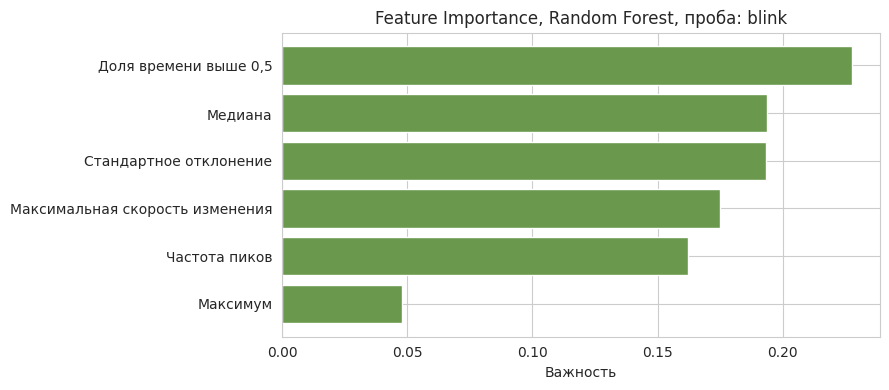

,Признак,Важность
0,"Доля времени выше 0,5",0.2275
1,Медиана,0.1938
2,Стандартное отклонение,0.1934
3,Максимальная скорость изменения,0.1751
4,Частота пиков,0.1623
5,Максимум,0.0480


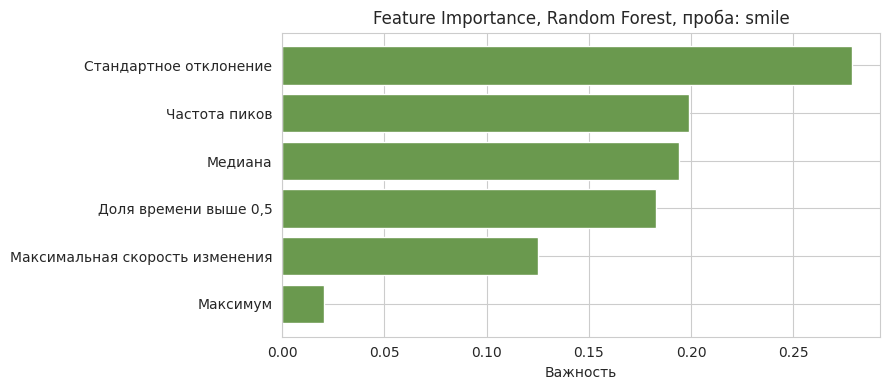

,Признак,Важность
0,Стандартное отклонение,0.2785
1,Частота пиков,0.1989
2,Медиана,0.1940
3,"Доля времени выше 0,5",0.1830
4,Максимальная скорость изменения,0.1249
5,Максимум,0.0207


In [10]:
for test, results in all_results.items():
    imp = results['Random Forest']['importances']
    if imp is None:
        continue
    imp_df = pd.DataFrame({'Признак': FEATURE_NAMES, 'Важность': imp}).sort_values('Важность', ascending=True)
    plt.figure(figsize=(9, 4))
    plt.barh(imp_df['Признак'], imp_df['Важность'], color='#6a994e')
    plt.xlabel('Важность')
    plt.title(f'Feature Importance, Random Forest, проба: {test}')
    plt.tight_layout()
    plt.show()
    display(imp_df.iloc[::-1].reset_index(drop=True).round(4))

## 10. Выводы

### Тест Манна-Уитни

Ни один признак не дал p < 0.05. При группах по 4 и 7 наблюдений тест просто не набирает мощности: минимально достижимое двустороннее p-value для n=4, n=7 около 0.06-0.07, поэтому отсутствие значимости здесь не значит, что признаки не разделяют группы. Ближе всего к порогу оказалась максимальная скорость изменения при зажмуривании (p = 0.103). При накоплении данных стоит вернуться к этому тесту первым.

### LOOCV, зажмуривание (n = 11, БП = 4, КГ = 7)

| Модель | Accuracy | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|
| Random Forest | 0.636 | 0.500 | **0.821** | 0.793 |
| SVM (RBF) | 0.545 | 0.444 | 0.000 | 0.269 |
| Логистическая регрессия | 0.636 | 0.600 | **0.821** | 0.768 |

Baseline PR-AUC (случайный классификатор) = 0.364.

Random Forest и логистическая регрессия дали ROC-AUC = 0.821, PR-AUC превышает baseline в 2.1-2.2 раза. Для пилотной выборки это хороший сигнал.

SVM получил ROC-AUC = 0.000. Это не вычислительная ошибка: AUC симметрична относительно 0.5, и значение 0.0 означает, что модель ранжирует пациентов ровно в обратном порядке. На маленькой выборке SVM с фиксированными гиперпараметрами (C = 1.0, RBF) оказался чувствителен к конкретному разбиению LOOCV. Random Forest и LogReg устойчивее в этом отношении.

### LOOCV, улыбка (n = 9, БП = 3, КГ = 6)

| Модель | Accuracy | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|
| Random Forest | 0.444 | 0.000 | 0.250 | 0.306 |
| SVM (RBF) | 0.444 | 0.000 | 0.000 | 0.242 |
| Логистическая регрессия | 0.556 | 0.333 | 0.333 | 0.333 |

Baseline PR-AUC = 0.333. Все три модели на уровне или ниже случайного. При n_БП = 3 в LOOCV на обучение уходят лишь 2 образца БП против 6 КГ, этого недостаточно, чтобы классификатор что-то выучил. Результаты по улыбке сейчас нельзя использовать как оценку метода.

### Разбор метрик

**Accuracy** обманчива при дисбалансе классов. Модель, предсказывающая всё как КГ, даст accuracy = 0.636 при соотношении 4:7, не обнаружив ни одного пациента. Поэтому ориентироваться нужно на F1 и ROC-AUC.

**F1** учитывает и точность, и полноту для класса БП. LogReg при зажмуривании дала F1 = 0.600, RF = 0.500.

**ROC-AUC** не зависит от порога классификации и от соотношения классов. Значение 0.821 означает, что в 82% случаев модель верно ранжирует случайно взятую пару (пациент БП, здоровый КГ). Стандартная ошибка AUC при n = 11 порядка 0.10-0.12, так что реальный доверительный интервал широкий, но как пилотный сигнал это хороший результат.

**PR-AUC** информативнее ROC-AUC когда положительный класс редкий. Baseline равен доле БП в выборке. RF при зажмуривании: PR-AUC = 0.793 при baseline 0.364, то есть в 2.2 раза выше случайного.

**Чувствительность и специфичность.** В медицинском скрининге эти метрики часто важнее accuracy. Чувствительность (sensitivity = TP / (TP + FN)), это доля верно найденных пациентов с БП. Специфичность - TN / (TN + FP), это доля верно определённых здоровых. При скрининге обычно важнее чувствительность: лучше ложная тревога, чем пропущенный пациент. Числа по каждой модели видны на confusion matrices в разделе 7.

### Информативность признаков

При зажмуривании лидирует "Доля времени выше 0,5" (важность 0.228). Это биологически осмыслено: при гипомимии Паркинсона пациент зажмуривается менее глубоко или медленнее, EAR дольше остаётся высоким. Следом идут медиана равная 0.194 и стандартное отклонение = 0.193, которые описывают общий уровень и вариабельность движения.

При улыбке первое место занимает стандартное отклонение (0.279). При гипомимии мимический индекс, вероятно, менее устойчив и имеет меньшую амплитуду, что сказывается на дисперсии ряда. Максимум оказался наименее важным признаком для обеих проб (0.048 и 0.021): пиковое значение индекса сильно зависит от анатомии лица конкретного человека и плохо обобщается между субъектами.

### Итог

Проба зажмуривания перспективнее улыбки: RF и LogReg дают ROC-AUC ≈ 0.82 уже на 11 наблюдениях. Для улыбки данных пока недостаточно. Главное ограничение это размер выборки. Необходимо больше сессий.